In [1]:
import os
os.getcwd()

'/home/jovyan'

In [ ]:
import nibabel as nb
from pathlib import Path
from nilearn import plotting
import numpy as np

In [3]:
# Check data
hcp_path = "shared/data/HCP-Aging"


In [4]:
from pathlib import Path

# Parent directory that holds all HCA subject folders
hcp_root = Path("shared/data/HCP-Aging")

hca_folders = sorted(
    p for p in hcp_root.iterdir()
    if p.is_dir() and p.name.startswith("HCA") and any(p.iterdir())
)

print(f"Found {len(hca_folders)} non-empty HCA* folders in {hcp_root}")
for p in hca_folders:
    print(p.name)

Found 53 non-empty HCA* folders in shared/data/HCP-Aging
HCA6002236_V3_MR
HCA6005242_V2_MR
HCA6007044_V3_MR
HCA6007044_V4_MR
HCA6016146_V2_MR
HCA6016146_V3_MR
HCA6018857_V3_MR
HCA6031344_V3_MR
HCA6031344_V4_MR
HCA6037457_V3_MR
HCA6054457_V3_MR
HCA6062456_V3_MR
HCA6072156_V3_MR
HCA6072156_V4_MR
HCA6130548_V2_MR
HCA6131449_V2_MR
HCA6166973_V3_MR
HCA6174770_V2_MR
HCA6183064_V2_MR
HCA6228767_V3_MR
HCA6276475_V3_MR
HCA6281872_V3_MR
HCA6283371_V2_MR
HCA6283371_V3_MR
HCA6290368_V3_MR
HCA6290368_V4_MR
HCA6291976_V2_MR
HCA6302349_V3_MR
HCA6330152_V3_MR
HCA6374576_V3_MR
HCA6397992_V2_MR
HCA6397992_V3_MR
HCA6427066_V3_MR
HCA6429272_V3_MR
HCA6429272_V4_MR
HCA6464678_V3_MR
HCA6474782_V3_MR
HCA6542470_V3_MR
HCA7348277_V3_MR
HCA7350567_V2_MR
HCA7434674_V2_MR
HCA7452272_V2_MR
HCA7452575_V3_MR
HCA7453981_V2_MR
HCA7453981_V3_MR
HCA7467588_V3_MR
HCA7469592_V3_MR
HCA7497395_V2_MR
HCA7497901_V3_MR
HCA7519581_V1_MR
HCA7530670_V3_MR
HCA7530670_V4_MR
HCA7536884_V2_MR


In [5]:
hca_folder_names = [p.name.removesuffix("_MR") for p in hca_folders]
hca_folders_csv = ", ".join(hca_folder_names)
print(hca_folders_csv)

HCA6002236_V3, HCA6005242_V2, HCA6007044_V3, HCA6007044_V4, HCA6016146_V2, HCA6016146_V3, HCA6018857_V3, HCA6031344_V3, HCA6031344_V4, HCA6037457_V3, HCA6054457_V3, HCA6062456_V3, HCA6072156_V3, HCA6072156_V4, HCA6130548_V2, HCA6131449_V2, HCA6166973_V3, HCA6174770_V2, HCA6183064_V2, HCA6228767_V3, HCA6276475_V3, HCA6281872_V3, HCA6283371_V2, HCA6283371_V3, HCA6290368_V3, HCA6290368_V4, HCA6291976_V2, HCA6302349_V3, HCA6330152_V3, HCA6374576_V3, HCA6397992_V2, HCA6397992_V3, HCA6427066_V3, HCA6429272_V3, HCA6429272_V4, HCA6464678_V3, HCA6474782_V3, HCA6542470_V3, HCA7348277_V3, HCA7350567_V2, HCA7434674_V2, HCA7452272_V2, HCA7452575_V3, HCA7453981_V2, HCA7453981_V3, HCA7467588_V3, HCA7469592_V3, HCA7497395_V2, HCA7497901_V3, HCA7519581_V1, HCA7530670_V3, HCA7530670_V4, HCA7536884_V2


In [ ]:
# check a sample subject
some_path = "shared/data/HCP-Aging/HCA6002236_V3_MR/MNINonLinear/Results/tfMRI_VISMOTOR_PA/tfMRI_VISMOTOR_PA_finalmask.nii.gz"

# Using os.path.exists()
if os.path.exists(some_path):
    print(f"File '{some_path}' exists.")
else:
    print(f"File '{some_path}' does not exist.")


File 'shared/data/HCP-Aging/HCA6002236_V3_MR/MNINonLinear/Results/tfMRI_VISMOTOR_PA/tfMRI_VISMOTOR_PA_finalmask.nii.gz' exists.


In [5]:
nii_image = nb.load(some_path)
nii_image.shape

(91, 109, 91)

## What is this file?

`tfMRI_VISMOTOR_PA_finalmask.nii.gz` is the **brain mask** for one task-fMRI run (Visual Motor task, PA phase-encoding direction) from the HCP-Aging minimal preprocessing pipeline. It's a binary volume (1 = inside-brain voxel, 0 = outside) in MNI152 space, used to mask the corresponding 4D BOLD timeseries (`tfMRI_VISMOTOR_PA.nii.gz`) in the same folder. Shape `(91, 109, 91)` = the standard 2mm MNI152 grid.

Below: inspect the header/affine, compute basic stats, see what else lives in the run folder, and visualize the mask.

In [13]:
# Header, affine, voxel size, datatype
print(nii_image.header)
print("\nAffine:\n", nii_image.affine)
print("\nVoxel size (mm):", nii_image.header.get_zooms())
print("Data dtype:", nii_image.get_data_dtype())

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.   2.   2.   2.   2.5  0.   0.   0. ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'6.0.5:9e026117'
aux_file        : b''
qform_code      : mni
sform_code      : mni
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 90.0
qoffset_y       : -126.0
qoffset_z       : -72.0
srow_x          : [-2

In [14]:
import numpy as np

mask_data = nii_image.get_fdata()
n_voxels = mask_data.size
n_brain = np.sum(mask_data > 0)

print("Unique values:", np.unique(mask_data))
print(f"Total voxels: {n_voxels}")
print(f"In-brain voxels: {int(n_brain)} ({100 * n_brain / n_voxels:.1f}%)")

Unique values: [0. 1.]
Total voxels: 902629
In-brain voxels: 225688 (25.0%)


In [15]:
# What else is in this run's results folder?
run_dir = Path(some_path).parent
for f in sorted(run_dir.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"{f.name:50s} {size_mb:8.2f} MB")

EVs                                                    0.00 MB
Movement_AbsoluteRMS.txt                               0.00 MB
Movement_AbsoluteRMS_mean.txt                          0.00 MB
Movement_Regressors.txt                                0.02 MB
Movement_RelativeRMS.txt                               0.00 MB
Movement_RelativeRMS_mean.txt                          0.00 MB
Physio_combined_267e11c1-7da3-47c4-b33e-125ea6c388f7.csv     1.03 MB
brainmask_fs.2.nii.gz                                  0.02 MB
fMRIQC                                                 0.00 MB
tfMRI_VISMOTOR_PA_Atlas_MSMAll_hp0_clean_rclean_tclean.dtseries.nii    67.82 MB
tfMRI_VISMOTOR_PA_Atlas_MSMAll_mean.dscalar.nii        1.00 MB
tfMRI_VISMOTOR_PA_Atlas_nonzero.stats.txt              0.00 MB
tfMRI_VISMOTOR_PA_Jacobian.nii.gz                      2.96 MB
tfMRI_VISMOTOR_PA_PhaseOne_gdc_dc.nii.gz               0.98 MB
tfMRI_VISMOTOR_PA_PhaseTwo_gdc_dc.nii.gz               0.98 MB
tfMRI_VISMOTOR_PA_SBRef.nii.gz  

In [18]:
some_path = "shared/data/HCP-Aging/HCA6002236_V3_MR/MNINonLinear/Results/tfMRI_VISMOTOR_PA/tfMRI_VISMOTOR_PA_mean.nii.gz"

### Explore nifti

In [8]:
nii_path = "shared/data/HCP-Aging/HCA6002236_V3_MR/MNINonLinear/Results/tfMRI_VISMOTOR_PA/tfMRI_VISMOTOR_PA_hp0_clean_rclean_tclean.nii.gz"

In [ ]:
nii_image = nb.load(nii_path)
nii_image.shape

(91, 109, 91, 184)

In [13]:
# Extract the data as a 4D NumPy array
data = nii_image.get_fdata()
# Calculate the mean along the time axis (axis 3, representing the 4th dimension)
mean_data = np.mean(data, axis=3)

In [ ]:
# Calculate the mean along the time axis (axis 3, representing the 4th dimension)
mean_data = np.mean(data, axis=3)

In [17]:
mean_img = nb.Nifti1Image(mean_data, nii_image.affine)


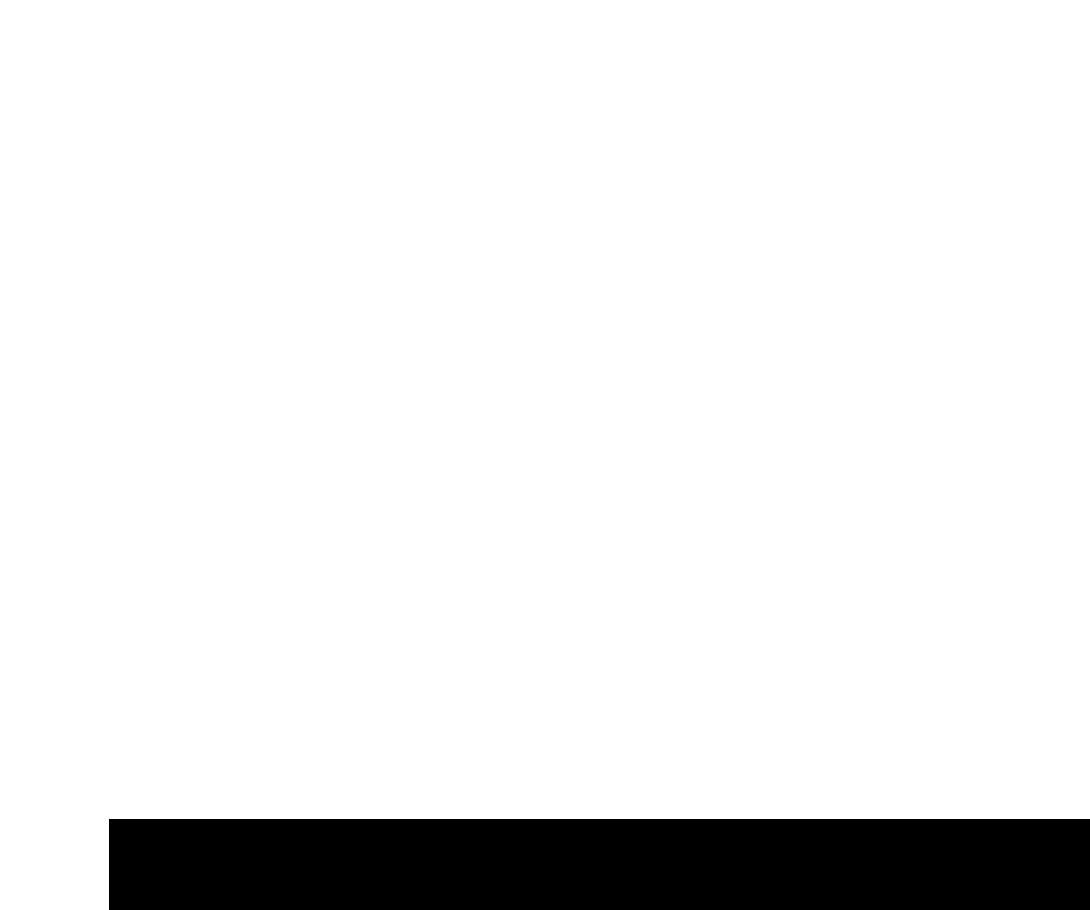
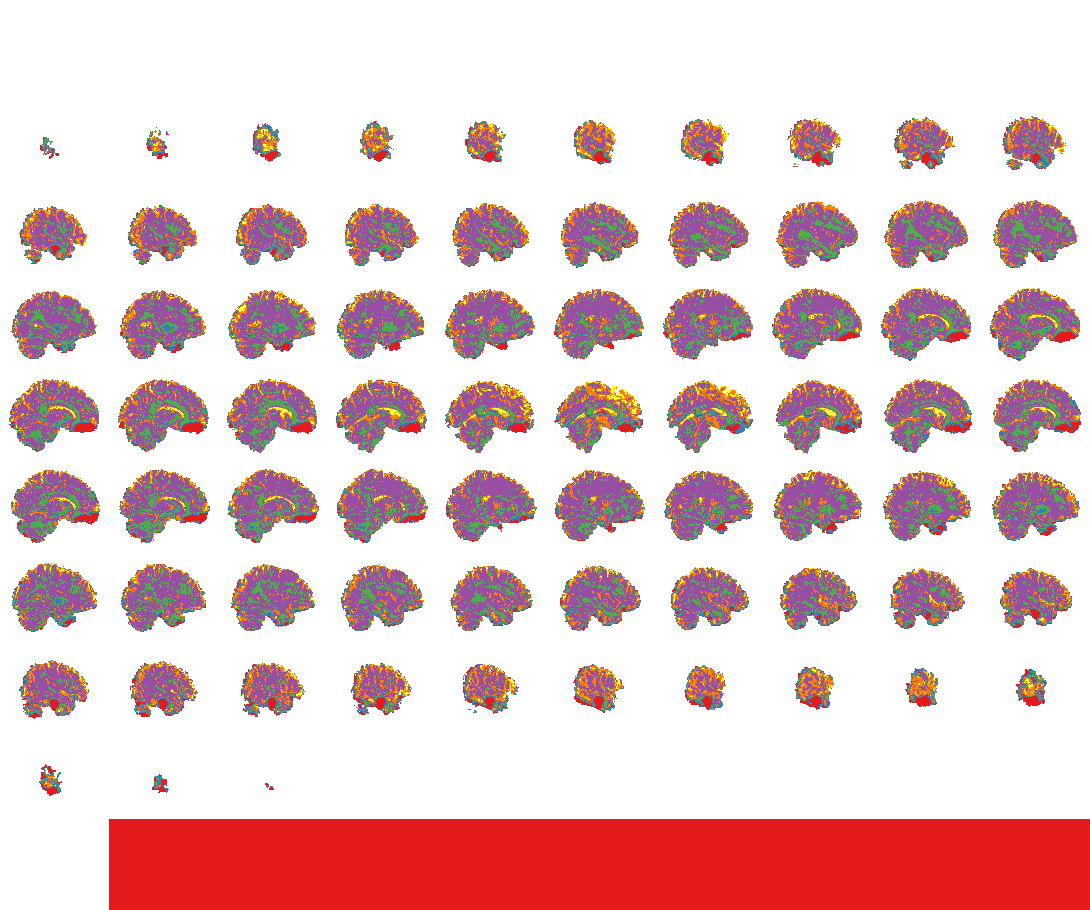

In [18]:
plotting.view_img(mean_img, bg_img=None, cmap="Set1", symmetric_cmap=False, colorbar=False)

In [21]:
from cloudpathlib import S3Path, S3Client
import nibabel as nib
import neuropythy as ny

# The base HCP path:
# base_path = S3Path(
#     's3://hcp-openaccess/HCP_1200/',
#     client=S3Client(profile_name='hcp'))

# Find an example cifti file:
# sid = 111312
# rs_dirpath = base_path / str(sid) / 'MNINonLinear' / 'Results' / 'rfMRI_REST1_7T_PA'
# cifti_filepath = rs_dirpath / 'rfMRI_REST1_7T_PA_Atlas_MSMAll_hp2000_clean.dtseries.nii'
cifti_filepath = "shared/data/HCP-Aging/HCA6002236_V3_MR/MNINonLinear/Results/tfMRI_VISMOTOR_PA/tfMRI_VISMOTOR_PA_Atlas_MSMAll_hp0_clean_rclean_tclean.dtseries.nii"

# Load the cifti object:
cii = nib.load(cifti_filepath)

(lhdat, rhdat, subdat) = ny.hcp.cifti_split(cii)
print('LH:', lhdat.shape)
print('RH:', rhdat.shape)

LH: (184, 32492)
RH: (184, 32492)


In [27]:
print(cii.nifti_header)

<class 'nibabel.cifti2.cifti2.LimitedNifti2Header'> object, endian='<'
sizeof_hdr      : 540
magic           : b'n+2'
eol_check       : [13 10 26 10]
datatype        : float32
bitpix          : 32
dim             : [    6     1     1     1     1   184 91282     1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0
scl_slope       : nan
scl_inter       : nan
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
slice_start     : 0
slice_end       : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : unknown
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : 0.0
qoffset_y       : 0.0
qoffset_z       : 0.0
srow_x          : [0. 0. 0. 0.]
srow_y          : [0. 0. 0. 0.]
srow_z          : [0. 0. 0. 0.]
slice_code      : unknown
xyzt_units      : 10
intent_code     : ConnDenseSeries
intent_name     : b'ConnDens

In [4]:
# Check structural files
path = "/home/jovyan/Structural"
import os
filenames = os.listdir(path)

In [6]:
import re
# Filter for files ending with "StructuralExtended.zip" and not ".md5"
filtered_files = [f for f in filenames if f.endswith("StructuralExtended.zip") and not f.endswith(".zip.md5")]

# Use a regex to extract the "HCAxxxxxxx_Vx" pattern
# The pattern looks for "HCA" followed by 7 digits, then "_V" and a digit
pattern = re.compile(r'(HCA\d{7}_V\d)')

extracted_ids = set()
for filename in filtered_files:
    match = pattern.search(filename)
    if match:
        extracted_ids.add(match.group(1))

print(f"Number of unique 'HCAxxxxxxx_Vx' IDs with 'StructuralExtended.zip': {len(extracted_ids)}")
print("Unique IDs:")
for uid in sorted(list(extracted_ids)):
    print(uid)

Number of unique 'HCAxxxxxxx_Vx' IDs with 'StructuralExtended.zip': 38
Unique IDs:
HCA6002236_V3
HCA6005242_V2
HCA6007044_V3
HCA6007044_V4
HCA6016146_V2
HCA6016146_V3
HCA6018857_V3
HCA6031344_V3
HCA6031344_V4
HCA6037457_V3
HCA6054457_V3
HCA6062456_V3
HCA6072156_V3
HCA6072156_V4
HCA6130548_V2
HCA6131449_V2
HCA6166973_V3
HCA6174770_V2
HCA6183064_V2
HCA6228767_V3
HCA6276475_V3
HCA6281872_V3
HCA6283371_V2
HCA6283371_V3
HCA6290368_V3
HCA6290368_V4
HCA6291976_V2
HCA6302349_V3
HCA6330152_V3
HCA6374576_V3
HCA6397992_V2
HCA6397992_V3
HCA6427066_V3
HCA6429272_V3
HCA6429272_V4
HCA6464678_V3
HCA6474782_V3
HCA6542470_V3


In [10]:
len(extracted_ids)

38

In [ ]:
#